# Show2D

`Show2D` renders one or many 2D images with contrast control, an FFT toggle, ROIs, line profiles, and a calibrated scale bar. It accepts a NumPy array, a PyTorch tensor, or a quantem `Dataset2d`.

Here we build a synthetic atomic-lattice image so the FFT shows clean lattice spots. The widget below is exported with `offline=True`, so it stays interactive in this static page.

```{note}
The widget below is exported with `offline=True`, which bakes the data as a **uint8 quantized** stack - kernel-less and 4x smaller than float32, visually identical after the colormap. This is the same packing `export_html(quantized=True)` writes for sharing.
```

In [1]:
import numpy as np

# Synthetic HAADF-like lattice: Gaussian atom columns on a square grid.
size = 512
row, col = np.mgrid[0:size, 0:size]
spacing = 24
image = np.zeros((size, size), dtype=np.float32)
sites = np.arange(spacing // 2, size, spacing)
for r0 in sites:
    for c0 in sites:
        image += np.exp(-((row - r0) ** 2 + (col - c0) ** 2) / (2 * 3.0 ** 2))
rng = np.random.default_rng(0)
image += 0.05 * rng.standard_normal((size, size)).astype(np.float32)
image.shape, image.dtype

((512, 512), dtype('float32'))

## Single image

`pixel_size=0.2` (Angstrom per pixel) calibrates the scale bar. Try the FFT toggle: the lattice spots appear at the grid frequency.

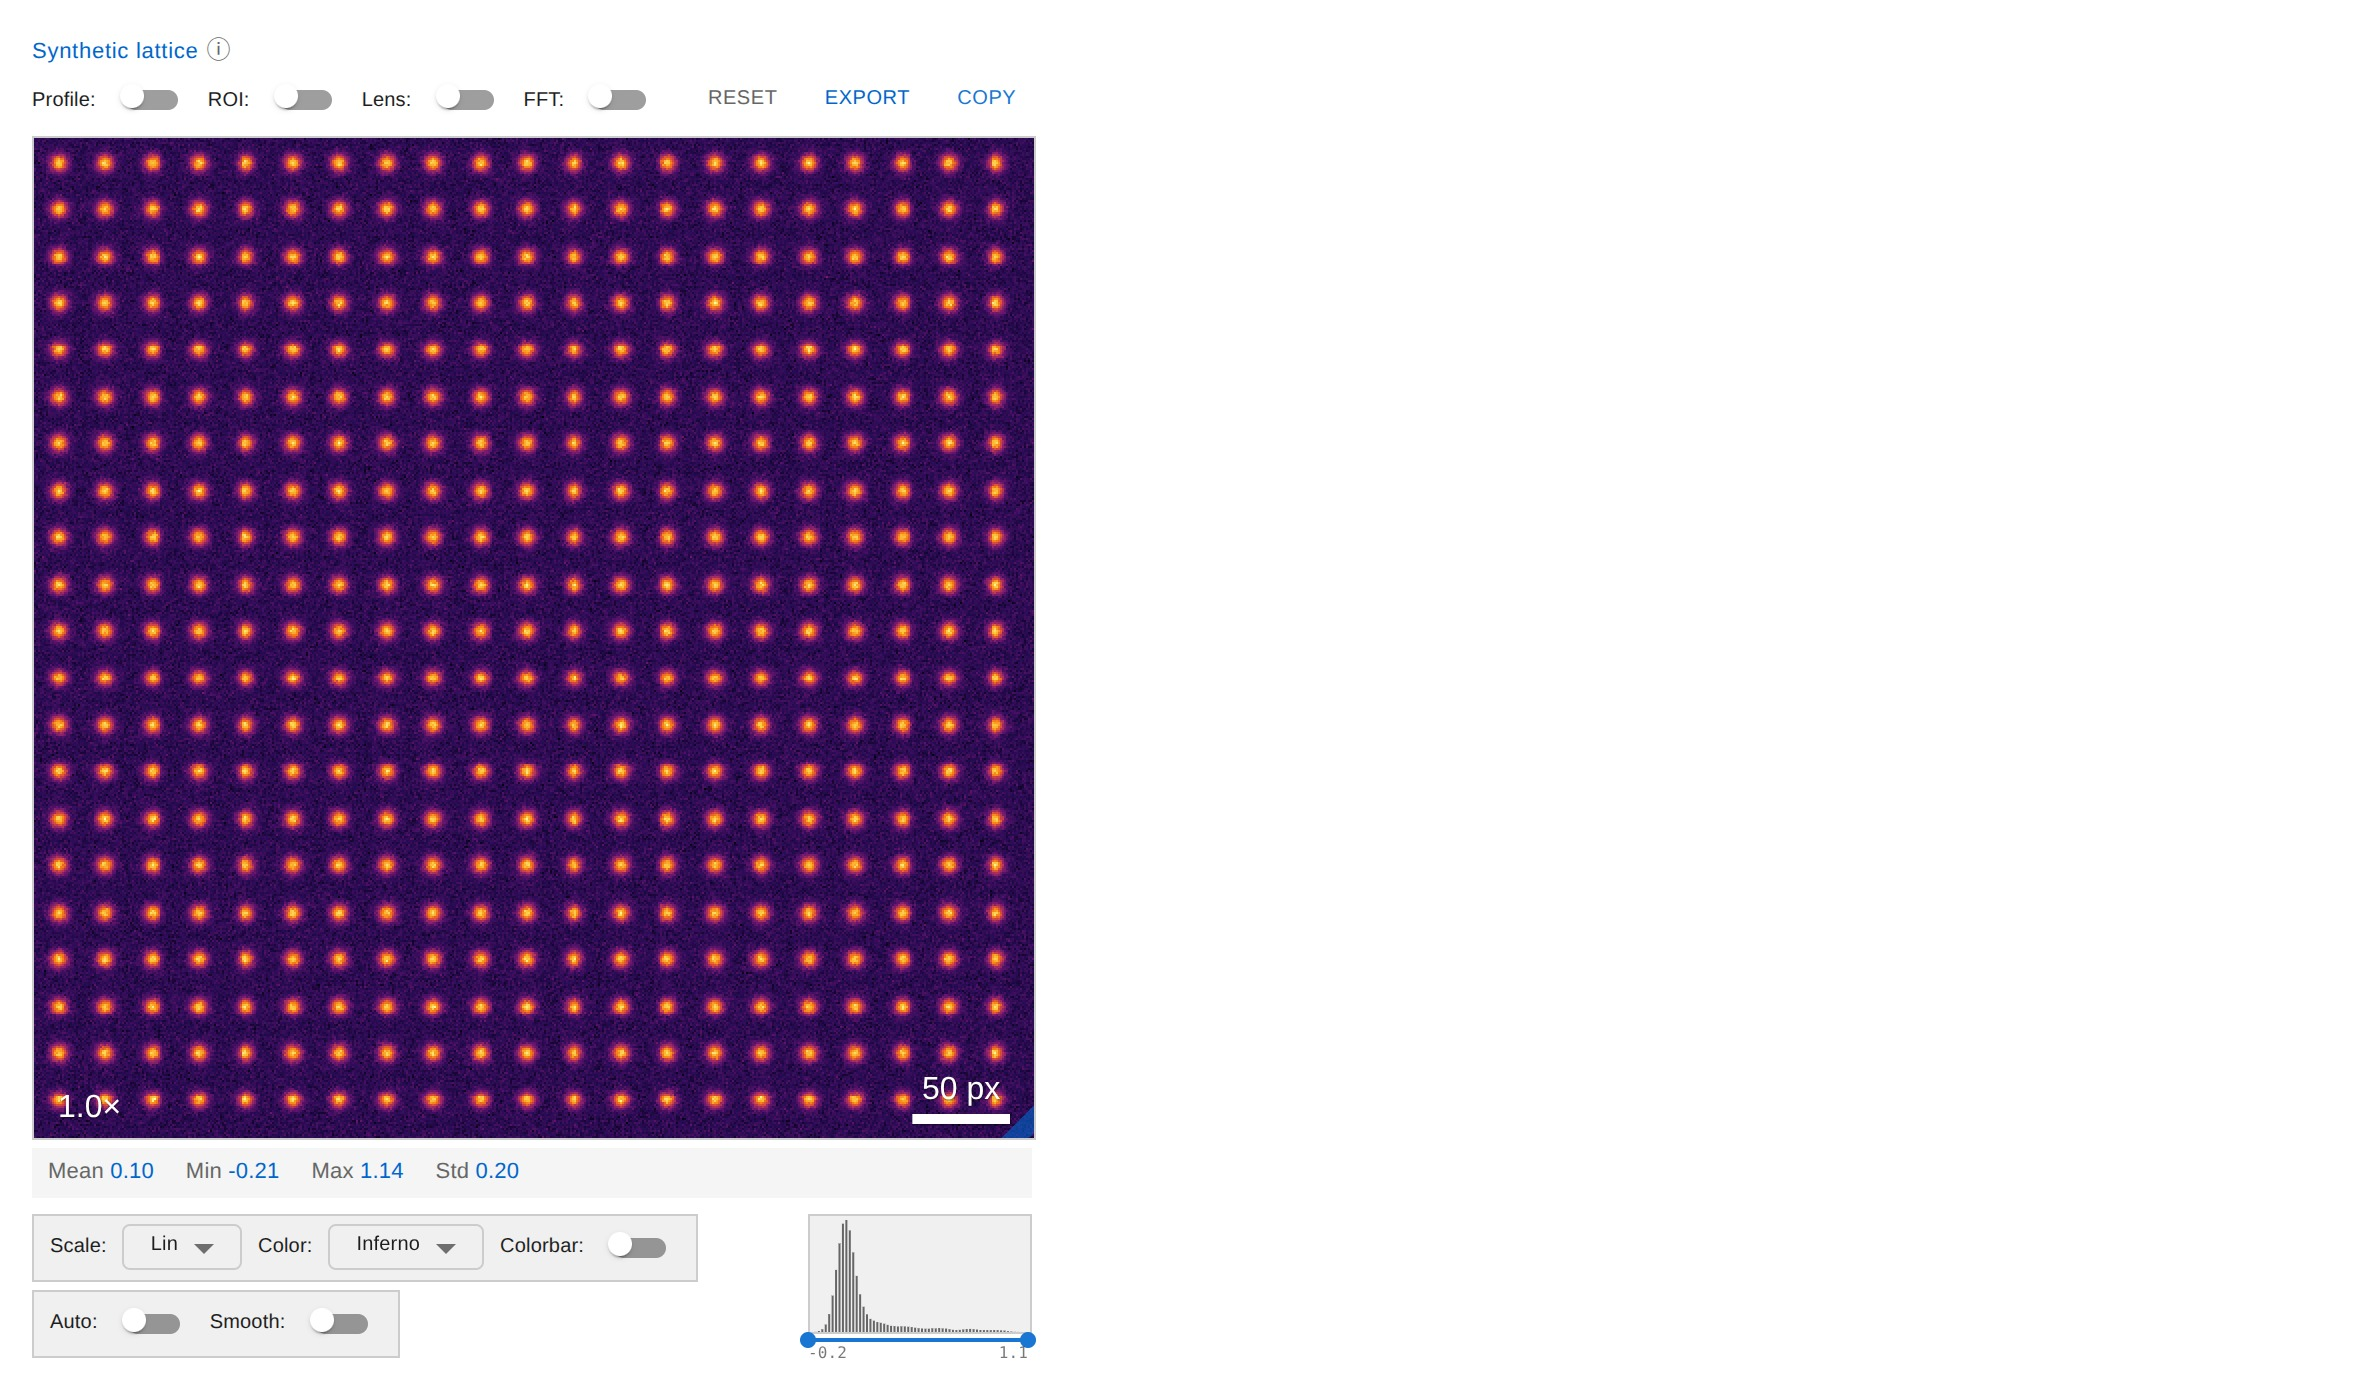

In [2]:
from quantem.widget import Show2D

Show2D(image, pixel_size=0.2, title='Synthetic lattice', offline=True)

## A gallery of images

Pass a list (or a stacked array) to compare images side by side; the contrast and zoom link across the panels.

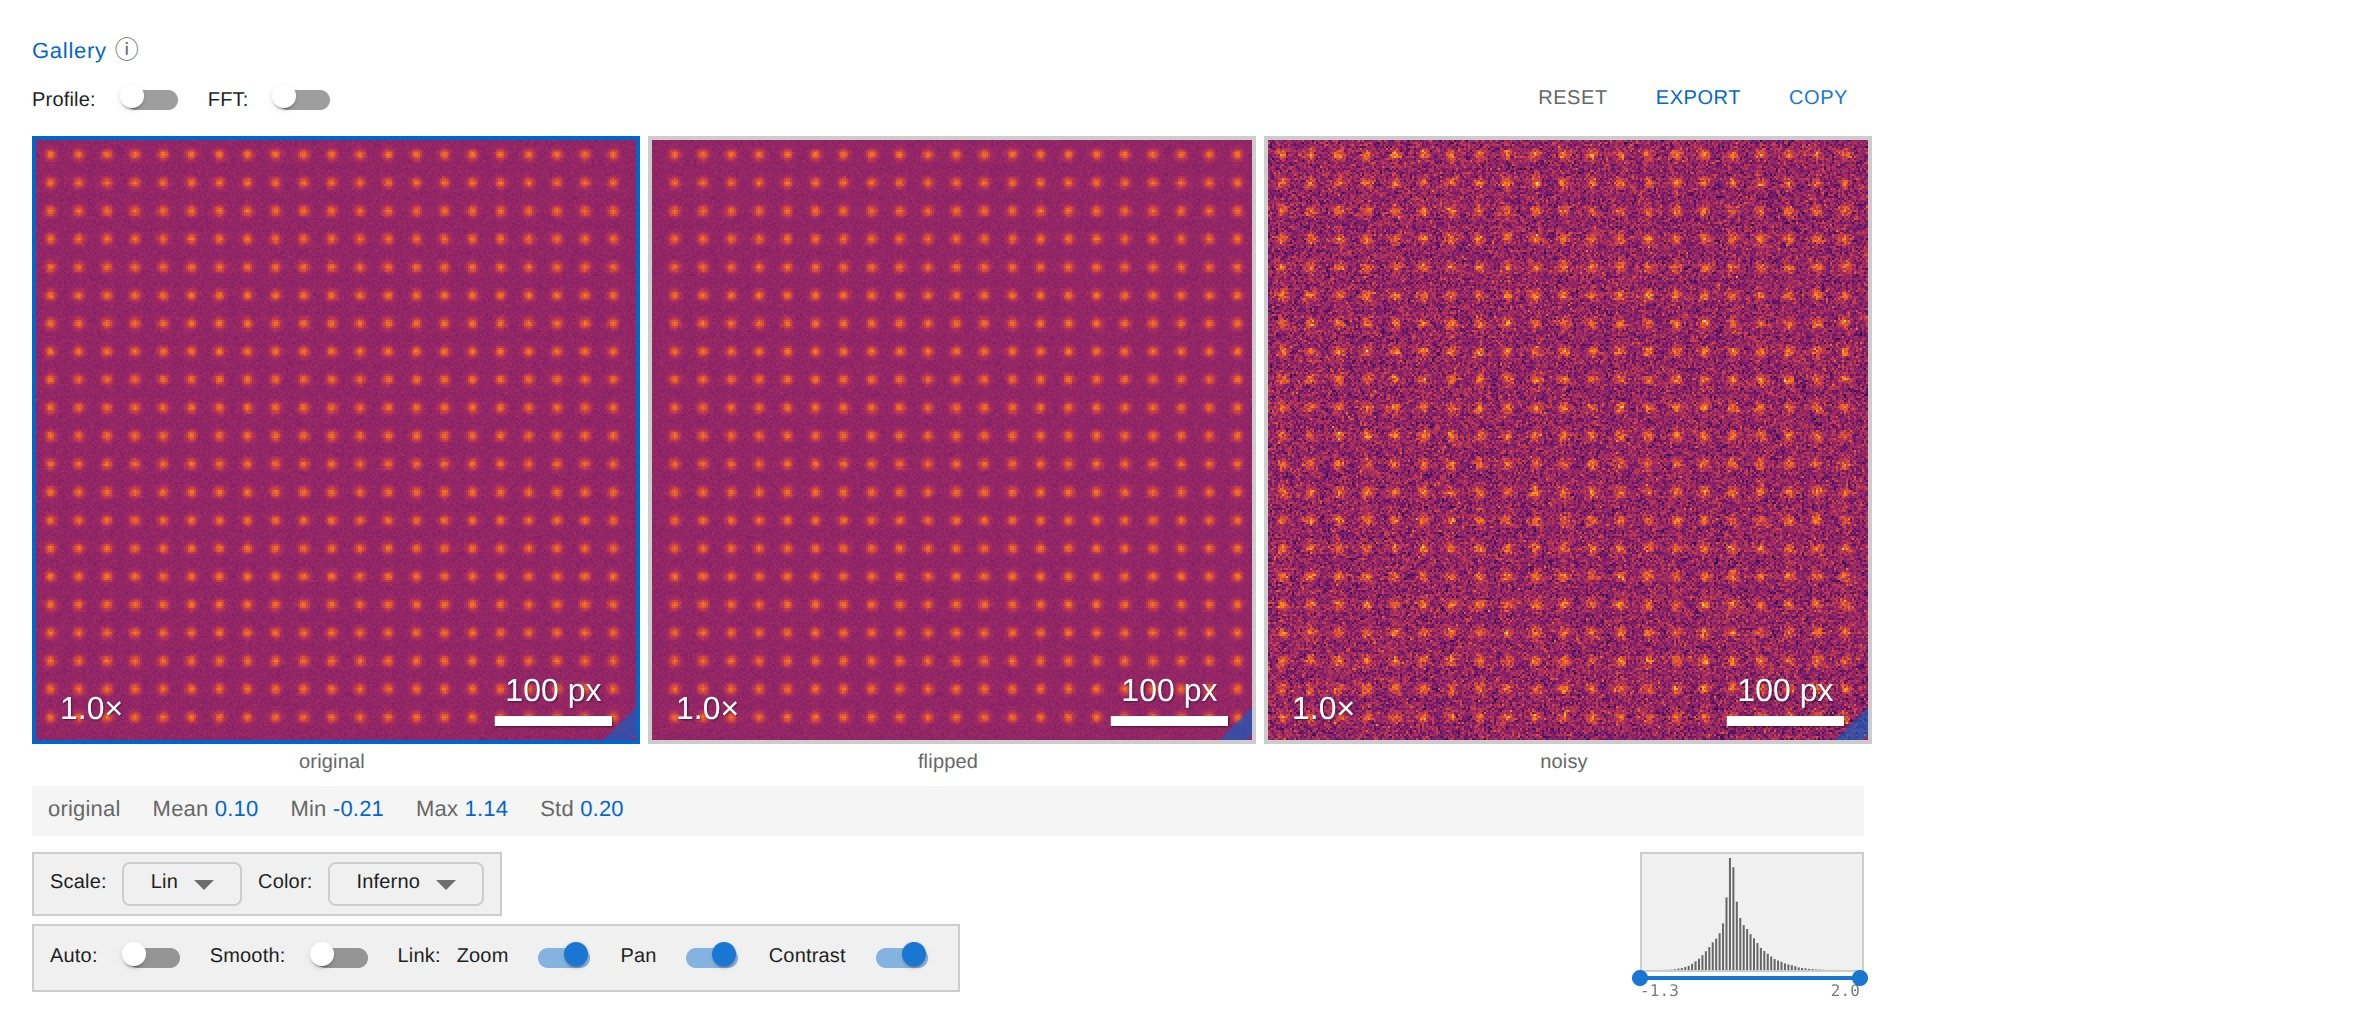

In [3]:
variants = [image, np.fliplr(image), image + 0.3 * rng.standard_normal(image.shape).astype(np.float32)]
Show2D(variants, labels=['original', 'flipped', 'noisy'], pixel_size=0.2, offline=True)